# Rhythmicity Analysis - Lomb-Scargle + Cosinor + JTK

Here we will be doing rhythmicity analysis of our activity tracks from R. padi that have survived a specific duration of time (aphids that only lived a few hours/1day should be excluded). 

In this interactive notebook we will configure a somewhat standard workflow.

**Pipeline**:
1. Set a few settings and import data
2. Run LS with FAP correction. Save the results.
3. Generate a summary table and some figures of the proportion rhythmic/non-rhythmic.
4. Show a periodogram for each individual/rep in a matrix plot. (large, ugly)
5. Grab the period detected in each periodogram and plot. Wilcoxon between LD and DD.
6. Grab phase (circular metric), by utilizing harmonic regression, in each individual. Plot and circular tests between LD and DD. 
7. From same regression model, estimate amplitude, mesor, and relative amplitude.
8. Plot regression model overtop of the activity data, allow activity data y-axis to scale.
9. Run JTK and compare between LS results at period of interest.

**Notes:**
(a) two peaks inside the search window are not independent, so a `Complex` rhythm (defined as two peaks in the search window) should not be interpreted as two rhythms.

(b) the periodogram will often be monotonic across the search window, with its maximum at an edge, these are counted separately as `Boundary`, not just as `Arrhythmic` 

(c) per-individual peak-period estimates carry uncertainty on the order of ~1 hour. 

## 1. Imports and configuration

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.timeseries import LombScargle
from scipy.signal import find_peaks
from scipy.stats import mannwhitneyu, wilcoxon, fisher_exact, vonmises

In [3]:
pd.set_option("display.width", 120)
plt.rcParams["svg.fonttype"] = "none"   # keep SVG text editable

# paths
INPUT_CSV = "../GenerateActivityBins/diet_1min_activity_downsample_rollingMean.csv"
OUT_DIR   = "./Results"
PLOT_DIR  = "./Plots"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# columns settings
TIME_COL   = "ZT_continuous"       # hours, continuous across days
VALUE_COL  = "filtered_distance"   # activity score
GROUP_COLS = ["treatment", "replicate", "individual"]

TREATMENTS     = ["LD-diet", "DD-diet"]   # order used in every figure
DISPLAY_LABELS = ["LD", "DD"]

# search/ inclusion params
MIN_PERIOD     = 20.0    # h
MAX_PERIOD     = 28.0    # h
MIN_SPAN_HOURS = 2 * MAX_PERIOD    # 56 h, 2x the longest period searched
N_FREQ         = 2000    # frequency grid points across the band

# FAP probability and peak
FAP_ALPHA             = 0.05   # Baluev false-alarm level, bounded to the search band
PEAK_MARGIN           = 1.25    # peak must exceed FAP_ALPHA level x this. Raise above 1.0 to do something similar to Beer et al., where narrow spikes barely above the FAP were deemed false positives.

MIN_PEAK_SEPARATION_H = 1.0    # minimum period separation between counted peaks, in hours
DETREND               = False  # subtract a linear trend before LS. Try True and compare, since multi-day diet activity declines/damps, and that low-frequency power can leak into the circadian band.

# data qc for min coverage
#MAX_GAP_HOURS  = None    # e.g. 6.0 to drop records with a >6 h hole
MIN_COVERAGE   = None    # e.g. 0.9 to require 90% of expected minute bin samples present

# plotting settings
TREATMENT_COLORS = {"LD-diet": "#EE99AA", "DD-diet": "#994455"}   # light / dark rose
RHYTHM_COLORS    = {"Simple": "#994455", "Complex": "#004488", "Arrhythmic": "#BBBBBB"}
RHYTHM_ORDER     = ["Simple", "Complex", "Arrhythmic"]

# individuals whose band maximum sits at an edge of the search window are classified arrythmic. Peak means peak not max.
# labelling these as boundary arrythmic..
BOUNDARY_COLOR   = "#CC3311"

# shading
DARK_START, DARK_END = 16.0, 24.0   # LD 16:08, scotophase shading on phase figures

print(f"Search band   : {MIN_PERIOD}-{MAX_PERIOD} h")
print(f"Min span      : {MIN_SPAN_HOURS} h")
print(f"Band width (freq)    : {1/MIN_PERIOD - 1/MAX_PERIOD:.5f} cyc/h")


Search band   : 20.0-28.0 h
Min span      : 56.0 h
Band width (freq)    : 0.01429 cyc/h


## 2. Lomb-Scargle functions

In [4]:
FREQS   = np.linspace(1.0 / MAX_PERIOD, 1.0 / MIN_PERIOD, N_FREQ)
PERIODS = 1.0 / FREQS
FREQ_STEP = FREQS[1] - FREQS[0]


def _separation_in_samples(sep_hours):
    """Convert a period separation (h) at mid-band into a number of grid samples."""
    p_mid = 0.5 * (MIN_PERIOD + MAX_PERIOD)
    d_freq = abs(1.0 / p_mid - 1.0 / (p_mid + sep_hours))
    return max(1, int(round(d_freq / FREQ_STEP)))


PEAK_SEPARATION_SAMPLES = _separation_in_samples(MIN_PEAK_SEPARATION_H)


def record_quality(t):
    """Span, largest gap, and sampling coverage for one individual's time vector."""
    t = np.sort(t)
    span = float(t.max() - t.min())
    if len(t) < 2:
        return span, np.nan, np.nan
    diffs = np.diff(t)
    step = float(np.median(diffs))
    max_gap = float(diffs.max())
    expected = span / step + 1 if step > 0 else np.nan
    coverage = float(len(t) / expected) if expected and np.isfinite(expected) else np.nan
    return span, max_gap, coverage


def cosinor(t, y, period):
    """OLS harmonic regression at a fixed period.

    Model: y = M + b1*cos(wt) + b2*sin(wt) = M + A*cos(w(t - t_peak))
    so the first peak after t = 0 sits at t_peak = atan2(b2, b1) * period / 2pi,
    which lies in [0, period).
    """
    w = 2.0 * np.pi / period
    X = np.column_stack([np.ones_like(t), np.cos(w * t), np.sin(w * t)])
    coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
    mesor, b1, b2 = coeffs
    amplitude = float(np.hypot(b1, b2))
    t_peak = float((np.arctan2(b2, b1) % (2.0 * np.pi)) * period / (2.0 * np.pi))

    resid = y - X @ coeffs
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = float(1.0 - np.sum(resid ** 2) / ss_tot) if ss_tot > 0 else np.nan
    return dict(mesor=float(mesor), amplitude=amplitude, t_peak=t_peak, cosinor_r2=r2)


def process_individual(t, y):
    """Lomb-Scargle + FAP + rhythm classification for one individual.

    Returns (stats dict, periodogram DataFrame) or (reason string, None) if excluded.
    """
    ok = np.isfinite(t) & np.isfinite(y)
    t, y = np.asarray(t)[ok], np.asarray(y)[ok]
    if len(t) < 10:
        return "too_few_points", None

    order = np.argsort(t)
    t, y = t[order], y[order]

    span, max_gap, coverage = record_quality(t)
    if span < MIN_SPAN_HOURS:
        return "span_below_minimum", None
    # removed max gap hours filtering
    # if MAX_GAP_HOURS is not None and np.isfinite(max_gap) and max_gap > MAX_GAP_HOURS:
    #     return "gap_too_large", None
    if MIN_COVERAGE is not None and np.isfinite(coverage) and coverage < MIN_COVERAGE:
        return "coverage_too_low", None

    y_fit = y - np.polyval(np.polyfit(t, y, 1), t) if DETREND else y
    if np.allclose(y_fit, y_fit[0]):
        return "no_variance", None

    ls = LombScargle(t, y_fit, normalization="standard")
    power = ls.power(FREQS)

    fap_level = float(ls.false_alarm_level(
        FAP_ALPHA, minimum_frequency=FREQS[0], maximum_frequency=FREQS[-1]))
    threshold = fap_level * PEAK_MARGIN

    peaks, _ = find_peaks(power, height=threshold, distance=PEAK_SEPARATION_SAMPLES)
    peaks = sorted(peaks, key=lambda i: power[i], reverse=True)

    best_idx = int(np.argmax(power))
    at_edge = best_idx in (0, len(power) - 1)

    secondary_period = secondary_power = np.nan

    arrhythmic_reason = ""

    if len(peaks) == 0:
        # Filtering for no peak inside the search window. Either the periodogram is truly flat, or
        # its maximum sits at an edge, which would mean the dominant period lies outside
        # MIN_PERIOD-MAX_PERIOD and the peak is an artefact of where the window was bounded.
        # both are considered arrhythmic but the cause is kept for diagnostics.
        peak_idx = best_idx
        rhythm_type, is_rhythmic = "Arrhythmic", False
        arrhythmic_reason = ("boundary" if (power[best_idx] > threshold and at_edge)
                             else "below_threshold")
    elif len(peaks) == 1:
        peak_idx = int(peaks[0])
        rhythm_type, is_rhythmic = "Simple", True
    else:
        peak_idx = int(peaks[0])
        secondary_period = float(PERIODS[peaks[1]])
        secondary_power = float(power[peaks[1]])
        rhythm_type, is_rhythmic = "Complex", True

    peak_period = float(PERIODS[peak_idx])
    peak_power = float(power[peak_idx])
    p_value = float(ls.false_alarm_probability(
        peak_power, minimum_frequency=FREQS[0], maximum_frequency=FREQS[-1]))

    fit = cosinor(t, y_fit, peak_period)
    # build a dictionary of stats from our analysis so far
    stats = dict(
        n_points=len(t), span_hours=span, max_gap_hours=max_gap, coverage=coverage,
        rhythm_type=rhythm_type, is_rhythmic=is_rhythmic,
        peak_period=peak_period, peak_power=peak_power, p_value=p_value,
        n_sig_peaks=len(peaks), peak_at_edge=at_edge,
        arrhythmic_reason=arrhythmic_reason,
        secondary_period=secondary_period, secondary_power=secondary_power,
        fap_level=fap_level, peak_threshold=threshold,
        amplitude=fit["amplitude"], mesor=fit["mesor"], cosinor_r2=fit["cosinor_r2"],
        # phase within the individual's own cycle (comparable across differing periods)
        phase_fraction=fit["t_peak"] / peak_period,
        # below is phase on the 24 h axis, or mod 24. note that phase actually may change across time due to drift from the absence of the plant or from DD...
        acrophase_zt=fit["t_peak"] % 24.0,
    )

    pg = pd.DataFrame({"period": PERIODS, "power": power})
    pg["peak_period"] = peak_period
    pg["peak_power"] = peak_power
    pg["fap_level"] = fap_level
    pg["rhythm_type"] = rhythm_type
    pg["arrhythmic_reason"] = arrhythmic_reason
    return stats, pg

## 3. Run the analysis and save results

In [5]:
print(f"Loading {INPUT_CSV} ...")
df = pd.read_csv(INPUT_CSV)

# convert pixel distances to cm, 281 pixels per cm
df[VALUE_COL] = df[VALUE_COL] / 281

missing = [c for c in GROUP_COLS + [TIME_COL, VALUE_COL] if c not in df.columns]
if missing:
    raise KeyError(f"Missing expected columns: {missing}")

df["treatment"] = df["treatment"].astype(str).str.strip()

stats_rows, pg_frames, excluded = [], [], []

grouped = df.groupby(GROUP_COLS, sort=True)
print(f"{len(grouped)} individuals found. Running Lomb-Scargle over "
      f"{MIN_PERIOD}-{MAX_PERIOD} h ...")

for keys, g in grouped:
    result, pg = process_individual(g[TIME_COL].to_numpy(), g[VALUE_COL].to_numpy())
    meta = dict(zip(GROUP_COLS, keys))
    if pg is None:
        excluded.append({**meta, "reason": result})
        continue
    stats_rows.append({**meta, **result})
    for k, v in meta.items():
        pg[k] = v
    pg_frames.append(pg)

if not stats_rows:
    raise RuntimeError("No individuals passed the inclusion criteria.")

stats_df = pd.DataFrame(stats_rows)
all_pg_df = pd.concat(pg_frames, ignore_index=True)
excluded_df = pd.DataFrame(excluded)

col_order = GROUP_COLS + [
    "n_points", "span_hours", "max_gap_hours", "coverage",
    "rhythm_type", "is_rhythmic", "n_sig_peaks", "peak_at_edge", "arrhythmic_reason",
    "peak_period", "peak_power", "p_value", "fap_level", "peak_threshold",
    "secondary_period", "secondary_power",
    "amplitude", "mesor", "cosinor_r2", "phase_fraction", "acrophase_zt",
]
stats_df = stats_df[col_order]

tag = f"{MIN_PERIOD:g}h_{MAX_PERIOD:g}h"
stats_path = os.path.join(OUT_DIR, f"Lomb_Scargle_Stats_{tag}.csv")
stats_df.to_csv(stats_path, index=False)
if len(excluded_df):
    excluded_df.to_csv(os.path.join(OUT_DIR, f"Excluded_Individuals_{tag}.csv"), index=False)

print(f"\nIncluded: {len(stats_df)}   Excluded: {len(excluded_df)}")
if len(excluded_df):
    print(excluded_df["reason"].value_counts().to_string())
print(f"\nSaved -> {stats_path}")

Loading ../GenerateActivityBins/diet_1min_activity_downsample_rollingMean.csv ...
96 individuals found. Running Lomb-Scargle over 20.0-28.0 h ...

Included: 73   Excluded: 23
reason
span_below_minimum    22
too_few_points         1

Saved -> ./Results\Lomb_Scargle_Stats_20h_28h.csv


In [6]:
# Here we will print some diagnostics to the console to check things out before doing any downstream analysis

# a general lifespan metric
print("Lifespan (h) by treatment:")
print(stats_df.groupby("treatment")["span_hours"]
      .describe()[["count", "min", "50%", "max"]].round(1).to_string())

# maximum gap in activity between LD and DD
if stats_df["max_gap_hours"].notna().any():
    print("\nLargest within-record gap (h) by treatment:")
    print(stats_df.groupby("treatment")["max_gap_hours"]
          .describe()[["50%", "max"]].round(2).to_string())

# some rhythmic/arrythmic stats and the accompanying reasons.
n_tot = len(stats_df)
n_boundary = int((stats_df["arrhythmic_reason"] == "boundary").sum())
n_below = int((stats_df["arrhythmic_reason"] == "below_threshold").sum())

print(f"\nArrhythmic by cause (of {n_tot} individuals):")
print(f"  band maximum at a {MIN_PERIOD:g}/{MAX_PERIOD:g} h edge (boundary) : "
      f"{n_boundary:3d} ({100 * n_boundary / n_tot:.1f}%)")
print(f"  peak power below the FAP threshold        : "
      f"{n_below:3d} ({100 * n_below / n_tot:.1f}%)")
print("\nA high boundary % means the dominant period often falls outside the band, "
      "and/or the band is too narrow relative to record length to localise a peak. "
      "Zero in the second row means every individual cleared the p < 0.05 level.")

Lifespan (h) by treatment:
           count   min   50%   max
treatment                         
DD-diet     39.0  76.0  96.0  96.0
LD-diet     34.0  57.0  95.3  96.0

Largest within-record gap (h) by treatment:
            50%   max
treatment            
DD-diet    0.02  0.08
LD-diet    0.02  0.12

Arrhythmic by cause (of 73 individuals):
  band maximum at a 20/28 h edge (boundary) :   9 (12.3%)
  peak power below the FAP threshold        :   0 (0.0%)

A high boundary % means the dominant period often falls outside the band, and/or the band is too narrow relative to record length to localise a peak. Zero in the second row means every individual cleared the p < 0.05 level.


## 4. Summary and rhythm-type breakdown

In [7]:
# some summary stats on the percentages of rhythmic classificiations and their reasons 

counts = (stats_df.groupby(["treatment", "rhythm_type"]).size()
          .unstack(fill_value=0).reindex(index=TREATMENTS, columns=RHYTHM_ORDER, fill_value=0))
pct = counts.div(counts.sum(axis=1), axis=0) * 100

print("Counts:")
print(counts.to_string())
print("\nPercent within treatment:")
print(pct.round(1).to_string())

counts.to_csv(os.path.join(OUT_DIR, f"Rhythm_Type_Counts_{tag}.csv"))

Counts:
rhythm_type  Simple  Complex  Arrhythmic
treatment                               
LD-diet          27        0           7
DD-diet          35        2           2

Percent within treatment:
rhythm_type  Simple  Complex  Arrhythmic
treatment                               
LD-diet        79.4      0.0        20.6
DD-diet        89.7      5.1         5.1


In [10]:
# here we can run some stat tests on the proportions we see between LD and DD.
# we consider simple and complex to be rhythmic

# 2x2 Fisher exact on rhythmic vs not (the exact, reportable test).
rhythmic = counts[["Simple", "Complex"]].sum(axis=1)
not_rhythmic = counts[["Arrhythmic"]].sum(axis=1)
table_2x2 = np.array([[rhythmic[t], not_rhythmic[t]] for t in TREATMENTS])
odds, p_fisher = fisher_exact(table_2x2)

print("Rhythmic vs non-rhythmic (Fisher's exact):")
for t, row in zip(TREATMENTS, table_2x2):
    print(f"  {t:8s} rhythmic {row[0]:3d} / {row.sum():3d} ({100*row[0]/row.sum():.1f}%)")
print(f"  odds ratio = {odds:.3f},  p = {p_fisher:.4g}")

# Full simple, rhythmic complex test. Not really of interest...

def contingency_permutation_test(count_table, n_perm=10000, seed=42):
    """Monte-Carlo permutation chi-square for the full RxC breakdown."""
    obs = np.asarray(count_table, dtype=float)

    def chi2(tab):
        exp = np.outer(tab.sum(1), tab.sum(0)) / tab.sum()
        with np.errstate(divide="ignore", invalid="ignore"):
            terms = np.where(exp > 0, (tab - exp) ** 2 / exp, 0.0)
        return terms.sum()

    labels = np.repeat(np.arange(obs.shape[0]), obs.sum(1).astype(int))
    cats = np.repeat(np.arange(obs.shape[1]), obs.sum(0).astype(int))
    stat = chi2(obs)
    rng = np.random.default_rng(seed)
    null = np.empty(n_perm)
    for k in range(n_perm):
        shuffled = rng.permutation(cats)
        tab = np.zeros_like(obs)
        for r in range(obs.shape[0]):
            sel = shuffled[labels == r]
            tab[r] = np.bincount(sel, minlength=obs.shape[1])
        null[k] = chi2(tab)
    return stat, (np.sum(null >= stat) + 1) / (n_perm + 1)


chi_stat, p_perm = contingency_permutation_test(counts.values, n_perm=5000)
#print(f"\nFull {counts.shape[0]}x{counts.shape[1]} breakdown "
#      f"(permutation chi-square): chi2 = {chi_stat:.3f}, p = {p_perm:.4g}")

Rhythmic vs non-rhythmic (Fisher's exact):
  LD-diet  rhythmic  27 /  34 (79.4%)
  DD-diet  rhythmic  37 /  39 (94.9%)
  odds ratio = 0.208,  p = 0.07262


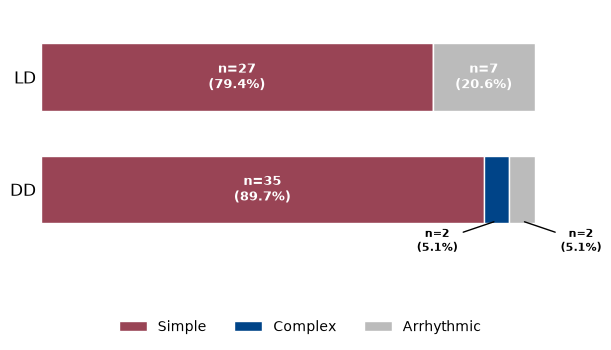

In [11]:
# making the stacked barplot figure for LD and DD.
fig, ax = plt.subplots(figsize=(6.2, 3.6))

left = np.zeros(len(TREATMENTS))
ypos = np.arange(len(TREATMENTS))

for r_type in RHYTHM_ORDER:
    vals = pct[r_type].values
    ns = counts[r_type].values
    ax.barh(ypos, vals, left=left, color=RHYTHM_COLORS[r_type],
            edgecolor="white", height=0.6, label=r_type)
    for i, (v, n) in enumerate(zip(vals, ns)):
        if v == 0:
            continue
        label = f"n={n}\n({v:.1f}%)"
        
        # Check if segment is wide enough for inline text
        if v >= 12:
            ax.text(left[i] + v / 2, i, label, ha="center", va="center",
                    color="white", fontweight="bold", fontsize=9)
        else:
            xc = left[i] + v / 2
            
            # Explicitly force DD (index 1) annotations to split outward left and right
            if i == 1:  # DD treatment row
                if r_type == "Complex":
                    # Force Complex annotation to angle to the left
                    text_x = xc - 12
                else:
                    # Force Arrhythmic annotation to angle to the right
                    text_x = xc + 12
            else:  # LD treatment row (default dynamic behavior)
                text_x = xc + (8 if xc > 50 else -8)

            ax.annotate(label, xy=(xc, i + 0.28),
                        xytext=(text_x, i + 0.58),
                        ha="center", va="bottom", fontsize=8, fontweight="bold",
                        arrowprops=dict(arrowstyle="-", color="black", lw=1.0))
    left += vals

ax.set_yticks(ypos)
ax.set_yticklabels(DISPLAY_LABELS, fontsize=12)
ax.set_xticks([])
ax.tick_params(axis="y", length=0)
for s in ("top", "right", "bottom", "left"):
    ax.spines[s].set_visible(False)
ax.set_ylim(-0.6, len(TREATMENTS))

# Invert y-axis to place LD on top of DD
ax.invert_yaxis()

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02),
          ncol=len(RHYTHM_ORDER), frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Rhythm_Breakdown_StackedBar.svg"),
            format="svg", bbox_inches="tight")
plt.show()

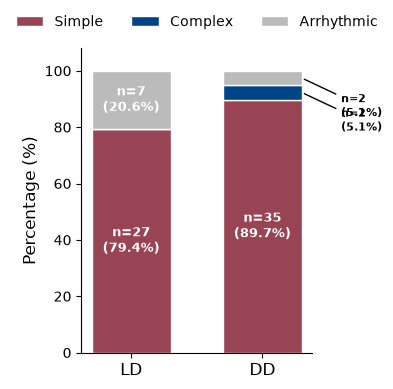

In [13]:
fig, ax = plt.subplots(figsize=(4, 4))

bottom = np.zeros(len(TREATMENTS))
xpos = np.arange(len(TREATMENTS))

for r_type in RHYTHM_ORDER:
    vals = pct[r_type].values
    ns = counts[r_type].values
    ax.bar(xpos, vals, bottom=bottom, color=RHYTHM_COLORS[r_type],
           edgecolor="white", width=0.6, label=r_type)
    for i, (v, n) in enumerate(zip(vals, ns)):
        if v == 0:
            continue
        label = f"n={n}\n({v:.1f}%)"
        
        if v >= 12:
            ax.text(i, bottom[i] + v / 2, label, ha="center", va="center",
                    color="white", fontweight="bold", fontsize=9)
        else:
            yc = bottom[i] + v / 2
            text_y = yc + (10 if yc < 50 else -10)
            ax.annotate(label, xy=(i + 0.3, yc),
                        xytext=(i + 0.6, text_y),
                        ha="left", va="center", fontsize=8, fontweight="bold",
                        arrowprops=dict(arrowstyle="-", color="black", lw=1.0))
    bottom += vals

ax.set_xticks(xpos)
ax.set_xticklabels(DISPLAY_LABELS, fontsize=12)
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_ylim(0, 108)

for s in ("top", "right"):
    ax.spines[s].set_visible(False)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15),
          ncol=len(RHYTHM_ORDER), frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Rhythm_Breakdown_StackedBar_Vertical.svg"),
            format="svg", bbox_inches="tight")
plt.show()

## 5. Matrix periodogram figure

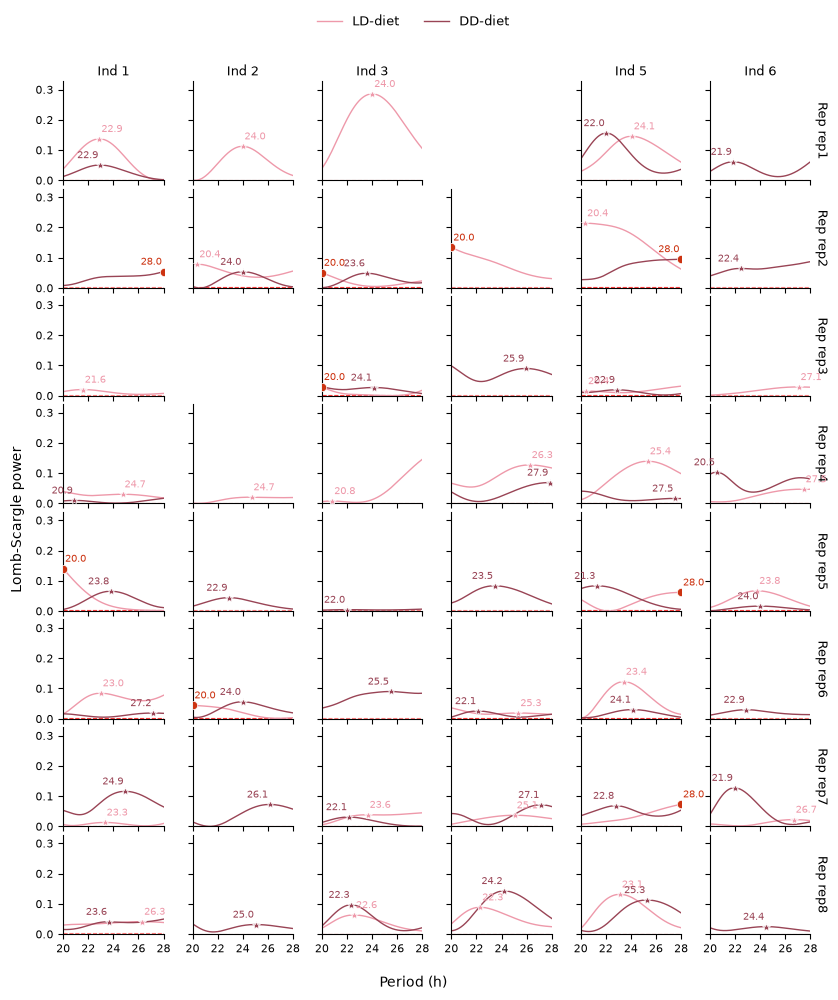

In [14]:
replicates  = sorted(all_pg_df["replicate"].unique())
individuals = sorted(all_pg_df["individual"].unique())
n_rows, n_cols = len(replicates), len(individuals)

y_limit = float(all_pg_df["power"].max()) * 1.15

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.4, n_rows * 1.2),
                         sharex=True, sharey=True, squeeze=False)

for r_idx, rep in enumerate(replicates):
    for c_idx, ind in enumerate(individuals):
        ax = axes[r_idx, c_idx]
        sub = all_pg_df[(all_pg_df["replicate"] == rep) & (all_pg_df["individual"] == ind)]

        if sub.empty:
            ax.axis("off")
            continue

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", labelsize=8)

        for treat in [t for t in TREATMENTS if t in sub["treatment"].values]:
            d = sub[sub["treatment"] == treat]
            color = TREATMENT_COLORS.get(treat, "black")

            ax.plot(d["period"], d["power"], color=color, lw=1.0, zorder=2, label=treat)
            ax.axhline(d["fap_level"].iloc[0], color="red", ls="--", lw=0.8,
                       alpha=0.5, zorder=1)

            pk_p, pk_pow = d["peak_period"].iloc[0], d["peak_power"].iloc[0]
            r_type = d["rhythm_type"].iloc[0]
            reason = d["arrhythmic_reason"].iloc[0]
            marker = "*" if r_type in ("Simple", "Complex") else "o"
            mark_color = BOUNDARY_COLOR if reason == "boundary" else color
            ax.plot(pk_p, pk_pow, marker=marker, color=mark_color, markersize=6,
                    markeredgecolor="white", markeredgewidth=0.5, zorder=3)
            ax.text(pk_p + (0.15 if treat == TREATMENTS[0] else -0.15), pk_pow + 0.015,
                    f"{pk_p:.1f}", fontsize=7, color=mark_color,
                    ha="left" if treat == TREATMENTS[0] else "right",
                    va="bottom", zorder=4)

        if r_idx == 0:
            ax.set_title(f"Ind {ind}", fontsize=9, pad=4)
        if c_idx == n_cols - 1:
            ax.text(1.05, 0.5, f"Rep {rep}", transform=ax.transAxes, rotation=270,
                    va="center", ha="left", fontsize=9)

plt.xlim(MIN_PERIOD, MAX_PERIOD)
plt.ylim(0, y_limit)
plt.xticks(np.arange(np.ceil(MIN_PERIOD), np.floor(MAX_PERIOD) + 1, 2))

fig.supxlabel("Period (h)", fontsize=10)
fig.supylabel("Lomb-Scargle power", fontsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    by_label = dict(zip(labels, handles))
    fig.legend(by_label.values(), by_label.keys(), loc="lower center",
               bbox_to_anchor=(0.5, 1.0), ncol=len(by_label), frameon=False, fontsize=9)

plt.tight_layout(pad=0.4, w_pad=0.1, h_pad=0.1, rect=[0.02, 0.02, 1, 0.98])

plt.savefig(os.path.join(PLOT_DIR, "Periodograms_Matrix.svg"),
            format="svg", bbox_inches="tight", pad_inches=0.05) # slight pad to prevent clipping
plt.show()

## 6. Period

In [15]:
# setting up functions to make our plot showing peak period between LD and DD with Wilcoxon test between them.

def p_to_stars(p):
    if p < 0.0001: return "****"
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"


def stat_bar(ax, x1, x2, y, text, h):
    ax.plot([x1, x1, x2, x2], [y - h, y, y, y - h], lw=1.0, c="black")
    ax.text((x1 + x2) / 2, y + h * 0.4, text, ha="center", va="bottom", fontsize=11)


def jitter_box(ax, data, positions, colors, seed=42):
    rng = np.random.default_rng(seed)
    for pos, d, c in zip(positions, data, colors):
        ax.scatter(pos + rng.uniform(-0.15, 0.15, size=len(d)), d,
                   facecolors=c, edgecolors="black", s=40, lw=1, alpha=0.85, zorder=1)
    bp = ax.boxplot(data, positions=positions, widths=0.4, patch_artist=True,
                    showfliers=False, zorder=2,
                    medianprops=dict(color="black", lw=2, zorder=3),
                    boxprops=dict(lw=1.5), whiskerprops=dict(lw=1.5),
                    capprops=dict(lw=1.5))
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)
    return bp

In [16]:
# summary stats of peak period. followed by U-test
sig = stats_df[stats_df["is_rhythmic"]].copy()
period_data = [sig.loc[sig["treatment"] == t, "peak_period"].dropna().values
               for t in TREATMENTS]

print("Peak period of rhythmic individuals:")
for t, d in zip(TREATMENTS, period_data):
    if len(d):
        print(f"  {t:8s} n={len(d):3d}  mean={d.mean():.2f} h  median={np.median(d):.2f} h  "
              f"SD={d.std(ddof=1):.2f}")

if all(len(d) > 0 for d in period_data):
    u, p_period = mannwhitneyu(period_data[0], period_data[1], alternative="two-sided")
    print(f"\nLD vs DD (Mann-Whitney U): U={u:.1f}, p={p_period:.4g}")
else:
    p_period = np.nan

Peak period of rhythmic individuals:
  LD-diet  n= 27  mean=23.80 h  median=23.76 h  SD=2.03
  DD-diet  n= 37  mean=23.78 h  median=23.63 h  SD=1.86

LD vs DD (Mann-Whitney U): U=516.0, p=0.8278


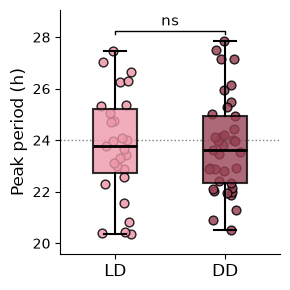

In [17]:
# now makigng the plot and overlaying the stat test results
fig, ax = plt.subplots(figsize=(3, 3))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

positions = [1, 2]
jitter_box(ax, period_data, positions, [TREATMENT_COLORS[t] for t in TREATMENTS])

ax.axhline(24.0, color="grey", ls=":", lw=1.0, zorder=0)

top = max(d.max() for d in period_data if len(d))
bar_y = top + 0.4
if np.isfinite(p_period):
    stat_bar(ax, positions[0], positions[1], bar_y, p_to_stars(p_period), h=0.15)

ax.set_xticks(positions)
ax.set_xticklabels(DISPLAY_LABELS, fontsize=12)
ax.set_ylim(MIN_PERIOD - 0.4, bar_y + 0.8)
ax.set_ylabel("Peak period (h)", fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Period_Boxplot_Jitter.svg"),
            format="svg", bbox_inches="tight")
plt.show()

## 7. Phase (acrophase)

Acrophase is technically a circular measure and isnt linear so we cannot treat it as such with tests that assume 0 and 24 are 24 units away.

Here we are plotting the phase, which might be from a signal with a period between 20-28, as mod 24.

For the DD group this is techincally free-running phase.

In [18]:
# some functions to help with circular statistics 
def circ_mean(hours, period=24.0):
    ang = np.asarray(hours) * 2 * np.pi / period
    C, S = np.cos(ang).mean(), np.sin(ang).mean()
    mu = np.arctan2(S, C) % (2 * np.pi)
    R = float(np.hypot(C, S))
    return mu * period / (2 * np.pi), R


def rayleigh_test(hours, period=24.0):
    """Rayleigh test of uniformity."""
    n = len(hours)
    _, R = circ_mean(hours, period)
    Z = n * R ** 2
    p = np.exp(-Z) * (1 + (2 * Z - Z ** 2) / (4 * n)
                      - (24 * Z - 132 * Z ** 2 + 76 * Z ** 3 - 9 * Z ** 4) / (288 * n ** 2))
    return R, Z, float(min(max(p, 0.0), 1.0))


def watson_u2(a, b):
    """Watson's two-sample U^2 statistic."""
    a, b = np.sort(np.asarray(a)), np.sort(np.asarray(b))
    n1, n2, N = len(a), len(b), len(a) + len(b)
    pooled = np.sort(np.concatenate([a, b]))
    d = np.searchsorted(a, pooled, side="right") / n1 - \
        np.searchsorted(b, pooled, side="right") / n2
    return (n1 * n2 / N ** 2) * (np.sum(d ** 2) - np.sum(d) ** 2 / N)


def watson_u2_test(a, b, n_perm=10000, seed=42):
    obs = watson_u2(a, b)
    pooled = np.concatenate([a, b])
    n1 = len(a)
    rng = np.random.default_rng(seed)
    null = np.array([watson_u2(*np.split(rng.permutation(pooled), [n1]))
                     for _ in range(n_perm)])
    return obs, (np.sum(null >= obs) + 1) / (n_perm + 1)

def circ_median(hours, period=24.0):
    """Calculate the circular median using a high-resolution grid search."""
    h = np.asarray(hours) % period
    grid = np.linspace(0, period, 2400)  # 0.01h resolution
    
    # Calculate shortest circular distance from all data points to all grid points
    diffs = np.abs(h[:, None] - grid) % period
    circ_dists = np.minimum(diffs, period - diffs)
    
    # The median is the grid point that minimizes the sum of distances
    return grid[np.argmin(np.sum(circ_dists, axis=0))]

In [19]:
# calculating and printing results
phase_data = [sig.loc[sig["treatment"] == t, "acrophase_zt"].dropna().values
              for t in TREATMENTS]

print("Acrophase (ZT/CT h) of rhythmic individuals:")
for t, d in zip(TREATMENTS, phase_data):
    if len(d) > 1:
        mu, R = circ_mean(d)
        _, Z, p_ray = rayleigh_test(d)
        print(f"  {t:8s} n={len(d):3d}  circular mean={mu:.2f} h  R={R:.3f}  "
              f"Rayleigh Z={Z:.2f}, p={p_ray:.4g}")

if all(len(d) > 1 for d in phase_data):
    u2, p_phase = watson_u2_test(phase_data[0], phase_data[1], n_perm=5000)
    print(f"\nLD vs DD (Watson's U^2, permutation): U2={u2:.4f}, p={p_phase:.4g}")
else:
    p_phase = np.nan

print("\nR is the mean resultant length: near 0 = acrophases are scattered, "
      "near 1 = tightly clustered. A non-significant Rayleigh test means there is no"
      "center (i.e mean) to compare in the first place.")

Acrophase (ZT/CT h) of rhythmic individuals:
  LD-diet  n= 27  circular mean=6.06 h  R=0.503  Rayleigh Z=6.83, p=0.0007564
  DD-diet  n= 37  circular mean=11.41 h  R=0.510  Rayleigh Z=9.63, p=3.678e-05

LD vs DD (Watson's U^2, permutation): U2=0.3959, p=0.0002

R is the mean resultant length: near 0 = acrophases are scattered, near 1 = tightly clustered. A non-significant Rayleigh test means there is nocenter (i.e mean) to compare in the first place.


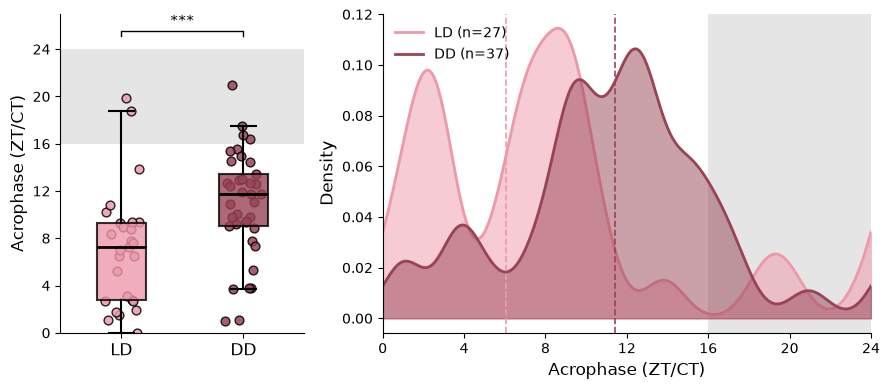

Dashed lines = circular means. Density uses a wrapped von Mises kernel, so it is continuous across ZT 24/0.


In [20]:
# now plotting the phase
fig, axes = plt.subplots(1, 2, figsize=(9, 4), gridspec_kw={"width_ratios": [1, 2]})

# boxplot on the left
ax = axes[0]
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.axhspan(DARK_START, DARK_END, facecolor="grey", alpha=0.2, zorder=0)

positions = [1, 2]
jitter_box(ax, phase_data, positions, [TREATMENT_COLORS[t] for t in TREATMENTS])

bar_y = 25.5
if np.isfinite(p_phase):
    stat_bar(ax, positions[0], positions[1], bar_y, p_to_stars(p_phase), h=0.4)

ax.set_xticks(positions)
ax.set_xticklabels(DISPLAY_LABELS, fontsize=12)
ax.set_ylim(0, bar_y + 1.5)
ax.set_yticks(np.arange(0, 25, 4))
ax.set_ylabel("Acrophase (ZT/CT)", fontsize=12)

# density plot on circular scale
ax = axes[1]
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.axvspan(DARK_START, DARK_END, facecolor="grey", alpha=0.2, zorder=0)

x_grid = np.linspace(0, 24, 400)
rad_grid = x_grid * 2 * np.pi / 24
KAPPA = 15   # ~1 h SD; lower = smoother

for treat, label in zip(TREATMENTS, DISPLAY_LABELS):
    d = sig.loc[sig["treatment"] == treat, "acrophase_zt"].dropna().values
    if len(d) < 2:
        continue
    dens = np.zeros_like(rad_grid)
    for pt in d * 2 * np.pi / 24:
        dens += vonmises.pdf(rad_grid, KAPPA, loc=pt)
    dens = dens / len(d) * (2 * np.pi / 24)   # change of variables back to hours

    color = TREATMENT_COLORS[treat]
    ax.plot(x_grid, dens, color=color, lw=2, label=f"{label} (n={len(d)})", zorder=2)
    ax.fill_between(x_grid, dens, color=color, alpha=0.5, zorder=2)

    mu, _ = circ_mean(d)
    ax.axvline(mu, color=color, ls="--", lw=1.2, zorder=3)

ax.set_xlim(0, 24)
ax.set_xticks(np.arange(0, 25, 4))
ax.set_xlabel("Acrophase (ZT/CT)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Acrophase_Figure.svg"), format="svg", bbox_inches="tight")
plt.show()

print("Dashed lines = circular means. Density uses a wrapped von Mises kernel, "
      "so it is continuous across ZT 24/0.")

Trying to put the boxplot in circular space with a circular median and mean... overlaying significance test done on circular mean.

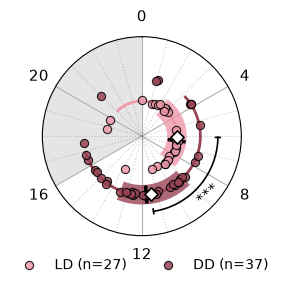

In [21]:
fig, ax = plt.subplots(figsize=(3, 3), subplot_kw={'projection': 'polar'})

# 0/24 on top
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# set grid/ticks
tick_hours = np.arange(0, 24, 4)
ax.set_xticks(tick_hours * 2 * np.pi / 24)
ax.set_xticklabels([f"{h}" for h in tick_hours], fontsize=11)

# minor ticks every 1 hour
minor_hours = np.arange(0, 24, 1)
ax.set_xticks(minor_hours * 2 * np.pi / 24, minor=True)

# tick line settings
#ax.grid(True, which='major', color='grey', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', color='grey', linestyle=':', alpha=0.4)

ax.set_yticks([])  # hide radial ticks
#ax.spines['polar'].set_visible(False) # give it an outline

# scotophase shading
mid_dark = (DARK_START + DARK_END) / 2 * (2 * np.pi / 24)
width_dark = (DARK_END - DARK_START) * (2 * np.pi / 24)
ax.bar(mid_dark, 3.4, width=width_dark, bottom=0, color='grey', alpha=0.2, zorder=0)

rng = np.random.default_rng(42)
means_rad = {}

for i, treat in enumerate(TREATMENTS):
    d = sig.loc[sig["treatment"] == treat, "acrophase_zt"].dropna().values
    if len(d) < 2: continue
    
    color = TREATMENT_COLORS[treat]
    r = 1.2 + i * 0.8  # radius tier for each treatment
    
    # calculate circular mean and median
    mu, _ = circ_mean(d)
    means_rad[treat] = mu * 2 * np.pi / 24
    
    med = circ_median(d)
    shifted = (d - med + 12) % 24 - 12
    q1, q3 = np.percentile(shifted, [25, 75])
    p5, p95 = np.percentile(shifted, [5, 95])
    
    # generate continuous arcs and then convert back to radians
    arc_iqr = (np.linspace(q1, q3, 50) + med) * 2 * np.pi / 24
    arc_whiskers = (np.linspace(p5, p95, 100) + med) * 2 * np.pi / 24
    med_rad = med * 2 * np.pi / 24
    mu_rad = means_rad[treat]
    
    # add whiskers (5th to 95th percentile)
    ax.plot(arc_whiskers, np.full(100, r), color=color, lw=2, zorder=2)
    
    # box of iqr
    ax.plot(arc_iqr, np.full(50, r), color=color, lw=14, solid_capstyle='butt', alpha=0.8, zorder=3)
    
    # circ median
    ax.plot([med_rad, med_rad], [r - 0.25, r + 0.25], color='black', lw=2.5, zorder=4)
    
    # circ mean, top z order
    ax.scatter([mu_rad], [r], marker='D', s=45, color='white', edgecolors='black', lw=1.2, zorder=6)
    
    # jitter
    angles = d * 2 * np.pi / 24
    jitter = rng.uniform(-0.06, 0.06, size=len(d))
    ax.scatter(angles, r + jitter, facecolors=color, edgecolors='black', 
               s=35, lw=0.8, alpha=0.85, zorder=5, label=f"{DISPLAY_LABELS[i]} (n={len(d)})")

# adding stat brackets, trying to make curved
if np.isfinite(p_phase) and len(means_rad) == 2:
    m1 = means_rad[TREATMENTS[0]]
    m2 = means_rad[TREATMENTS[1]]
    
    # radius span for the bracket, spanning outside the outermost ring at ~r=2.0
    r_bracket = 2.6
    
    # arc points for the connecting bracket line
    bracket_arc = np.linspace(m1, m2, 100)
    ax.plot(bracket_arc, np.full(100, r_bracket), color="black", lw=1.2, zorder=6)
    
    # end ticks pointing inward toward the circular means
    ax.plot([m1, m1], [r_bracket - 0.08, r_bracket + 0.08], color="black", lw=1.2, zorder=6)
    ax.plot([m2, m2], [r_bracket - 0.08, r_bracket + 0.08], color="black", lw=1.2, zorder=6)
    
    # midpoint for placing the asterisks/text label
    mid_angle = (m1 + m2) / 2
    
    # convert midpoint angle to degrees and calculate tangent rotation so the label is correctly placed
    rot_deg = np.degrees(mid_angle) - 90
    if np.cos(mid_angle) < 0:  # flip text if it's on the left side so it's never upside down, asterisks should be fine though
        rot_deg += 180

    ax.text(mid_angle, r_bracket + 0.15, p_to_stars(p_phase), 
            ha="center", va="center", fontsize=11, rotation=rot_deg, zorder=7)

ax.set_ylim(0, 3.4)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Acrophase_Circular_Boxplot.svg"), format="svg")
plt.show()

## 8. Cosinor Metrics

 Cosinor amplitude at each individual's LS peak period, LD vs DD.

- mesor           overall activity level the oscillation sits on
- amplitude       half the peak-to-trough swing, in units of VALUE_COL
- rel_amplitude   amplitude / mesor, the best between-group comparison

All three are plotted together so it is clear whether a group difference is in the
oscillation or just in how active the animals are.

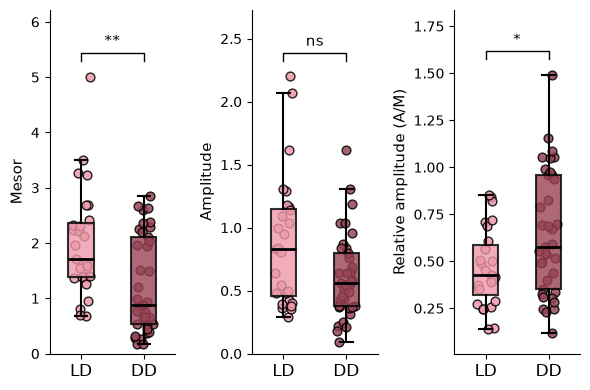

Cosinor amplitude metrics (rhythmic individuals only):

Mesor
  LD  n= 27  median=1.7141
  DD  n= 37  median=0.8738
  Mann-Whitney U=719.0, p=0.00291, 

Amplitude
  LD  n= 27  median=0.8319
  DD  n= 37  median=0.5566
  Mann-Whitney U=643.0, p=0.0519, 

Relative amplitude (A/M)
  LD  n= 27  median=0.4289
  DD  n= 37  median=0.5761
  Mann-Whitney U=348.0, p=0.0401, 



In [26]:
# starting the amp results

AMPLITUDE_RHYTHMIC_ONLY = True   # false to include Boundary/Arrhythmic as quick check

amp_src = (stats_df[stats_df["is_rhythmic"]] if AMPLITUDE_RHYTHMIC_ONLY else stats_df).copy()
amp_src["rel_amplitude"] = amp_src["amplitude"] / amp_src["mesor"]

AMP_METRICS = [
    ("mesor",         "Mesor"),
    ("amplitude",     "Amplitude"),
    ("rel_amplitude", "Relative amplitude (A/M)"),
]

fig, axes = plt.subplots(1, len(AMP_METRICS), figsize=(6, 4))
amp_results = {}

for ax, (col, ylab) in zip(np.atleast_1d(axes), AMP_METRICS):
    data = [amp_src.loc[amp_src["treatment"] == t, col].dropna().values for t in TREATMENTS]

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    positions = [1, 2]
    jitter_box(ax, data, positions, [TREATMENT_COLORS[t] for t in TREATMENTS])

    # we can use wilcoxon here since these are linear metrics, unlike phase
    if all(len(d) > 0 for d in data):
        u, p = mannwhitneyu(data[0], data[1], alternative="two-sided")
        rbc = 1.0 - 2.0 * u / (len(data[0]) * len(data[1]))
        amp_results[col] = dict(U=u, p=p, rank_biserial=rbc,
                                n_LD=len(data[0]), n_DD=len(data[1]),
                                median_LD=float(np.median(data[0])),
                                median_DD=float(np.median(data[1])))
    else:
        p = np.nan

    lo = min(d.min() for d in data if len(d))
    hi = max(d.max() for d in data if len(d))
    span = (hi - lo) or 1.0
    bar_y = hi + 0.09 * span
    if np.isfinite(p):
        stat_bar(ax, positions[0], positions[1], bar_y, p_to_stars(p), h=0.03 * span)

    ax.set_xticks(positions)
    ax.set_xticklabels(DISPLAY_LABELS, fontsize=12)
    ax.set_ylim(max(0, lo - 0.08 * span), bar_y + 0.16 * span)
    ax.set_ylabel(ylab, fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Amplitude_Boxplot_Jitter.svg"),
            format="svg", bbox_inches="tight")
plt.show()

# calculating metrics and printing to console
print(f"Cosinor amplitude metrics "
      f"({'rhythmic individuals only' if AMPLITUDE_RHYTHMIC_ONLY else 'all individuals'}):\n")
for col, ylab in AMP_METRICS:
    r = amp_results.get(col)
    if r is None:
        continue
    print(f"{ylab}")
    print(f"  LD  n={r['n_LD']:3d}  median={r['median_LD']:.4f}")
    print(f"  DD  n={r['n_DD']:3d}  median={r['median_DD']:.4f}")
    print(f"  Mann-Whitney U={r['U']:.1f}, p={r['p']:.4g}, \n")

amp_table = pd.DataFrame(amp_results).T
amp_table.to_csv(os.path.join(OUT_DIR, f"Amplitude_Comparison_{tag}.csv"))

## 9. Session summary

In [27]:
summary = {
    "search_band_h": f"{MIN_PERIOD}-{MAX_PERIOD}",
    "min_span_h": MIN_SPAN_HOURS,
    #"detrended": DETREND,
    "peak_margin": PEAK_MARGIN,
    "n_included": len(stats_df),
    "n_excluded": len(excluded_df),
    "n_arrhythmic_boundary": int((stats_df["arrhythmic_reason"] == "boundary").sum()),
    "n_arrhythmic_below_thresh": int((stats_df["arrhythmic_reason"] == "below_threshold").sum()),
    "median_span_h": round(float(stats_df["span_hours"].median()), 1),
}
for k, v in summary.items():
    print(f"{k:16s}: {v}")

#pd.DataFrame([summary]).to_csv(
#    os.path.join(OUT_DIR, f"Analysis_Parameters_{tag}.csv"), index=False)

search_band_h   : 20.0-28.0
min_span_h      : 56.0
peak_margin     : 1.25
n_included      : 73
n_excluded      : 23
n_arrhythmic_boundary: 9
n_arrhythmic_below_thresh: 0
median_span_h   : 96.0


# QC plots. 

We should overlay our fit harmonic regression model (using the LS period detected) to see if the data in question is well represented by these sin/cosine wave.

saved -> ./Plots\Cosinor_Overlay_LD_diet.svg


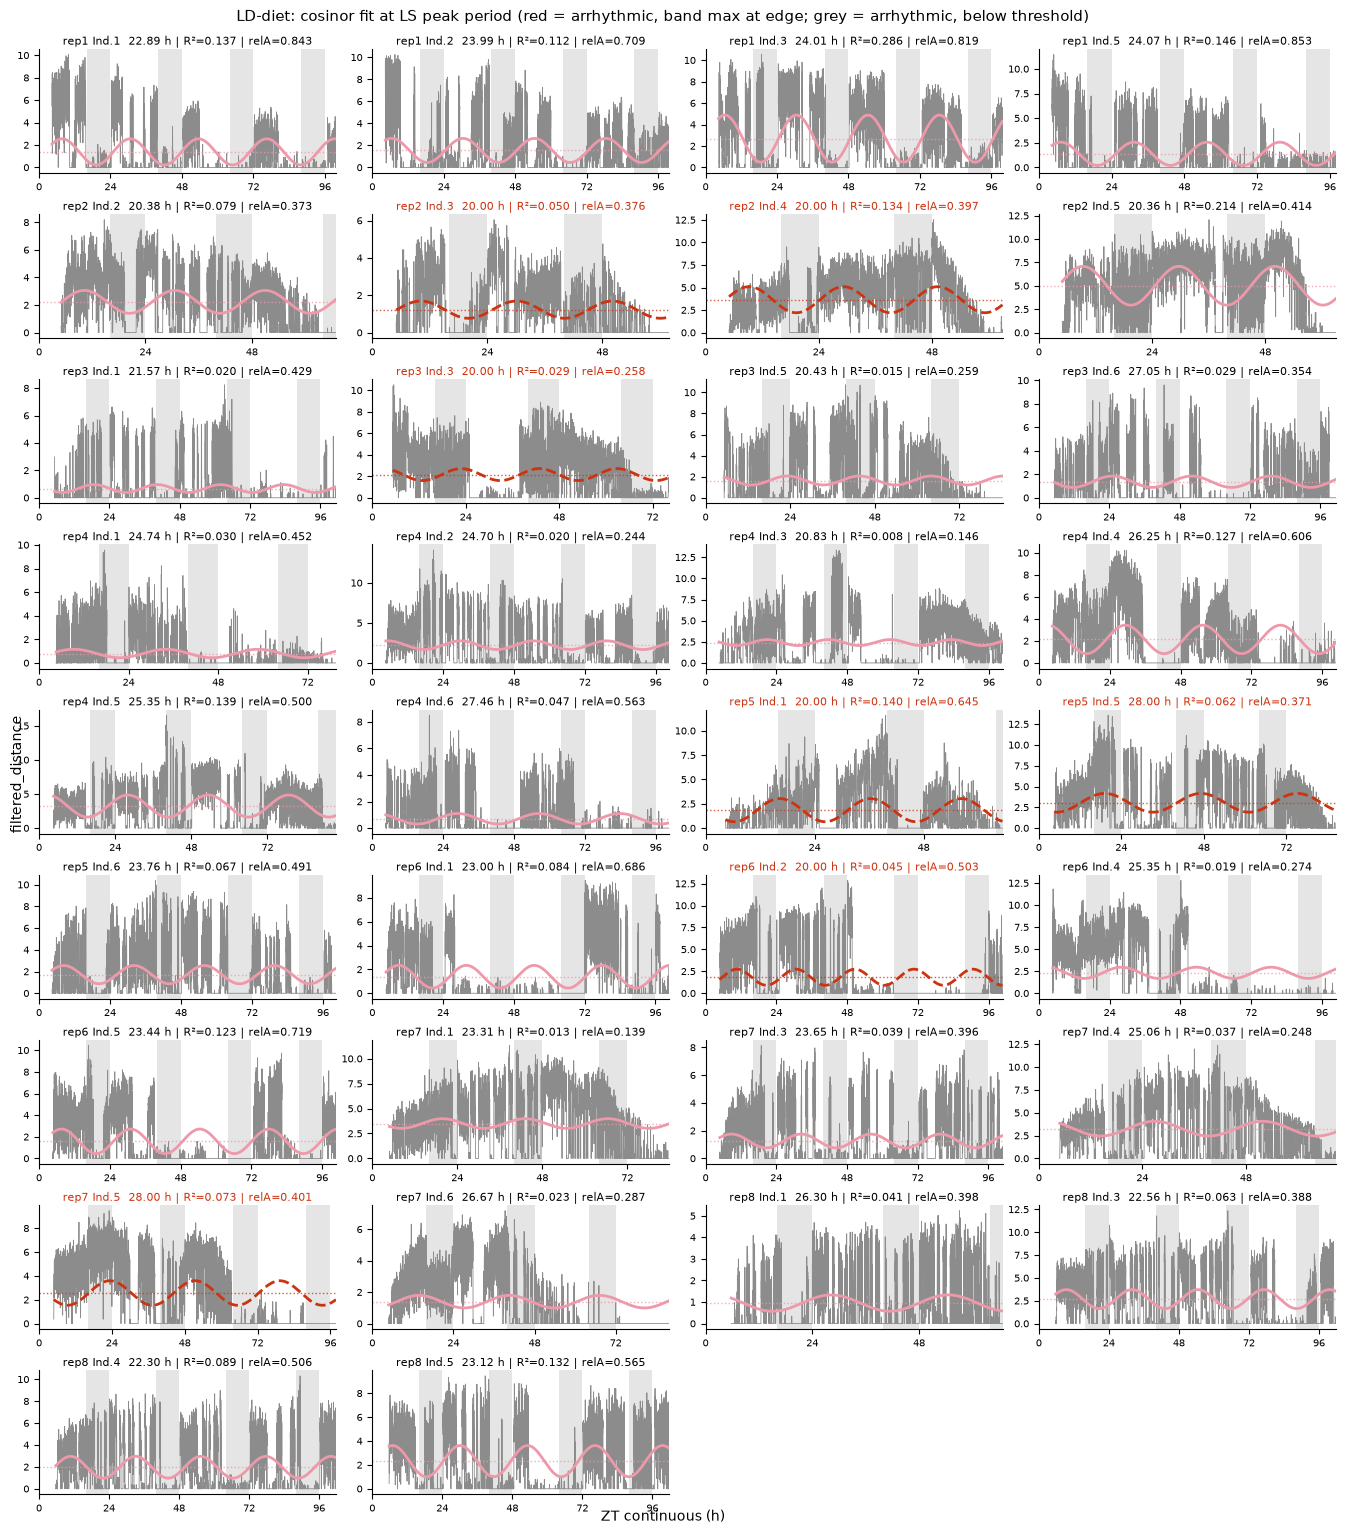

saved -> ./Plots\Cosinor_Overlay_DD_diet.svg


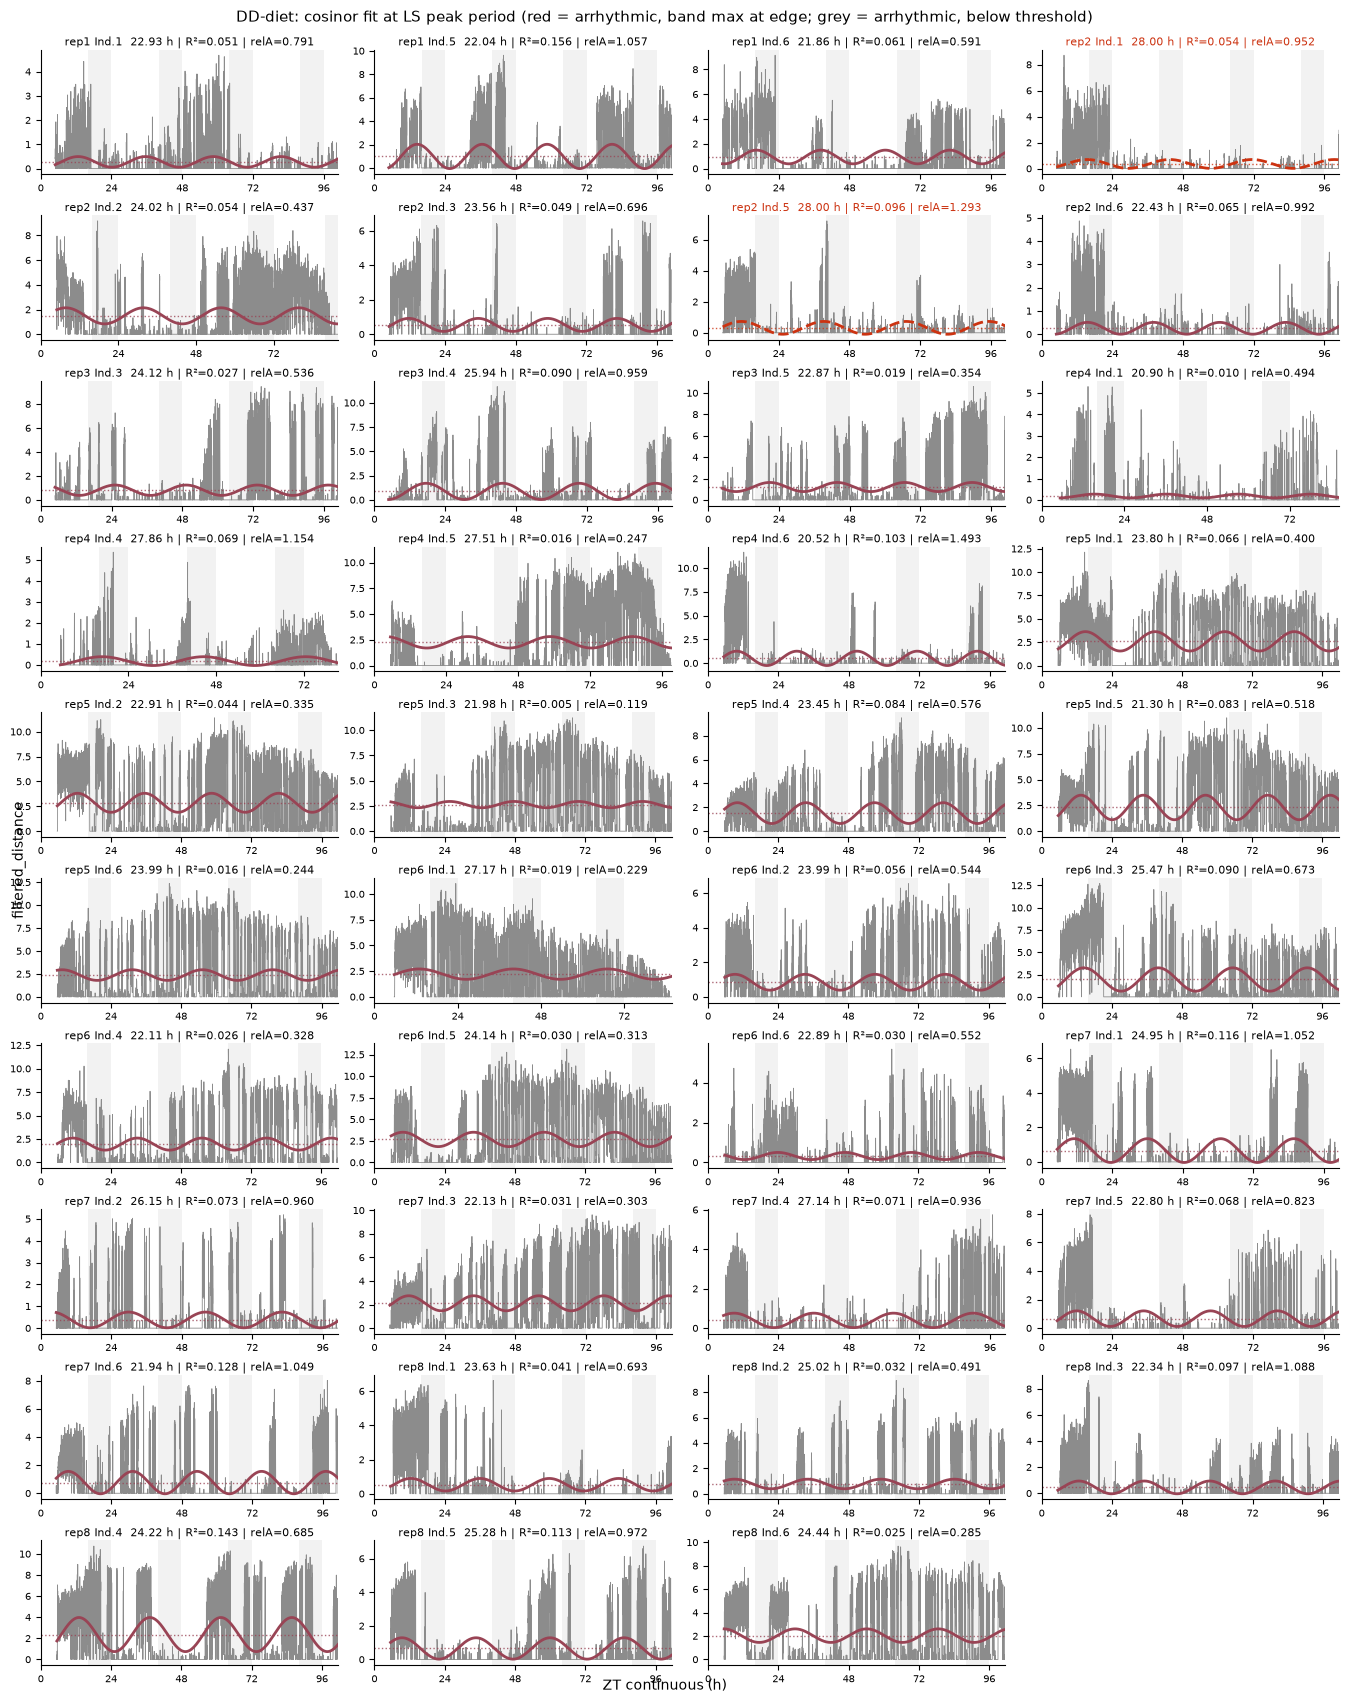


Cosinor variance explained and relative amplitude, by treatment:
          cosinor_r2        rel_amplitude       
                 50%    max           50%    max
treatment                                       
DD-diet        0.056  0.156         0.591  1.493
LD-diet        0.062  0.286         0.407  0.853


In [28]:
# start
# note that this is just a diagnostic and not explicit results.
# these models are directly from above, no refitting.

# title colour legend:
#   black  rhythmic (simple or complex)
#   red    arrhythmic because the band maximum sat at an edge of the search window
#   grey   arrhythmic because peak power never cleared the FAP threshold


SHOW_DARK_SHADING = True  
OVERLAY_NCOL      = 4

TITLE_COLORS = {"": "black", "boundary": BOUNDARY_COLOR, "below_threshold": "0.45"}


def cosinor_curve(t, row):
    P = float(row["peak_period"])
    t_peak = float(row["phase_fraction"]) * P
    return float(row["mesor"]) + float(row["amplitude"]) * np.cos(2 * np.pi * (t - t_peak) / P)


def plot_cosinor_overlay(treatment, ncol=OVERLAY_NCOL, panel_size=(3.4, 1.7), save=True):
    sub = (stats_df[stats_df["treatment"] == treatment]
           .sort_values(["replicate", "individual"]))
    if sub.empty:
        print(f"No individuals for {treatment}")
        return

    n = len(sub)
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, squeeze=False,
                             figsize=(panel_size[0] * ncol, panel_size[1] * nrow))
    flat = axes.ravel()
    color = TREATMENT_COLORS.get(treatment, "black")
    is_dd = "DD" in treatment

    for ax, (_, row) in zip(flat, sub.iterrows()):
        d = (df[(df["treatment"] == row["treatment"]) &
                (df["replicate"] == row["replicate"]) &
                (df["individual"] == row["individual"])]
             .dropna(subset=[TIME_COL, VALUE_COL])
             .sort_values(TIME_COL))
        t = d[TIME_COL].to_numpy(dtype=float)
        y = d[VALUE_COL].to_numpy(dtype=float)
        if len(t) == 0:
            ax.axis("off")
            continue

        # dark / subjective-dark shading
        if SHOW_DARK_SHADING:
            for k in range(int(np.floor(t.min() / 24)), int(np.ceil(t.max() / 24)) + 1):
                ax.axvspan(DARK_START + 24 * k, DARK_END + 24 * k,
                           facecolor="grey", alpha=0.10 if is_dd else 0.20,
                           lw=0, zorder=0)

        ax.plot(t, y, color="0.55", lw=0.6, zorder=1)

        reason = row.get("arrhythmic_reason", "")
        fit_color = BOUNDARY_COLOR if reason == "boundary" else color
        fit_style = "--" if not row["is_rhythmic"] else "-"

        t_fine = np.linspace(t.min(), t.max(), 2000)
        ax.plot(t_fine, cosinor_curve(t_fine, row), color=fit_color, lw=2.0,
                ls=fit_style, zorder=3)
        ax.axhline(row["mesor"], color=fit_color, ls=":", lw=1.0, alpha=0.8, zorder=2)

        rel_amp = row["amplitude"] / row["mesor"] if row["mesor"] else np.nan
        title = (f"{row['replicate']} Ind.{row['individual']}  "
                 f"{row['peak_period']:.2f} h | R\u00b2={row['cosinor_r2']:.3f} | "
                 f"relA={rel_amp:.3f}")
        ax.set_title(title, fontsize=8, pad=3, color=TITLE_COLORS.get(reason, "black"))

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(labelsize=7)
        ax.set_xlim(t.min(), t.max())
        ax.set_xticks(np.arange(0, t.max(), 24))

    for ax in flat[n:]:
        ax.axis("off")

    fig.supxlabel("ZT continuous (h)", fontsize=10)
    fig.supylabel(VALUE_COL, fontsize=10)
    fig.suptitle(f"{treatment}: cosinor fit at LS peak period "
                 f"(red = arrhythmic, band max at edge; grey = arrhythmic, below threshold)",
                 fontsize=11, y=1.0)
    plt.tight_layout(pad=0.4, w_pad=0.4, h_pad=0.6)

    if save:
        out = os.path.join(PLOT_DIR, f"Cosinor_Overlay_{treatment.replace('-', '_')}.svg")
        plt.savefig(out, format="svg", bbox_inches="tight")
        print(f"saved -> {out}")
    plt.show()


for _t in TREATMENTS:
    plot_cosinor_overlay(_t)

# how much oscillation is the significant rhythm actually describing.
stats_df["rel_amplitude"] = stats_df["amplitude"] / stats_df["mesor"]
print("\nCosinor variance explained and relative amplitude, by treatment:")
print(stats_df.groupby("treatment")[["cosinor_r2", "rel_amplitude"]]
      .describe()[[("cosinor_r2", "50%"), ("cosinor_r2", "max"),
                   ("rel_amplitude", "50%"), ("rel_amplitude", "max")]].round(3).to_string())

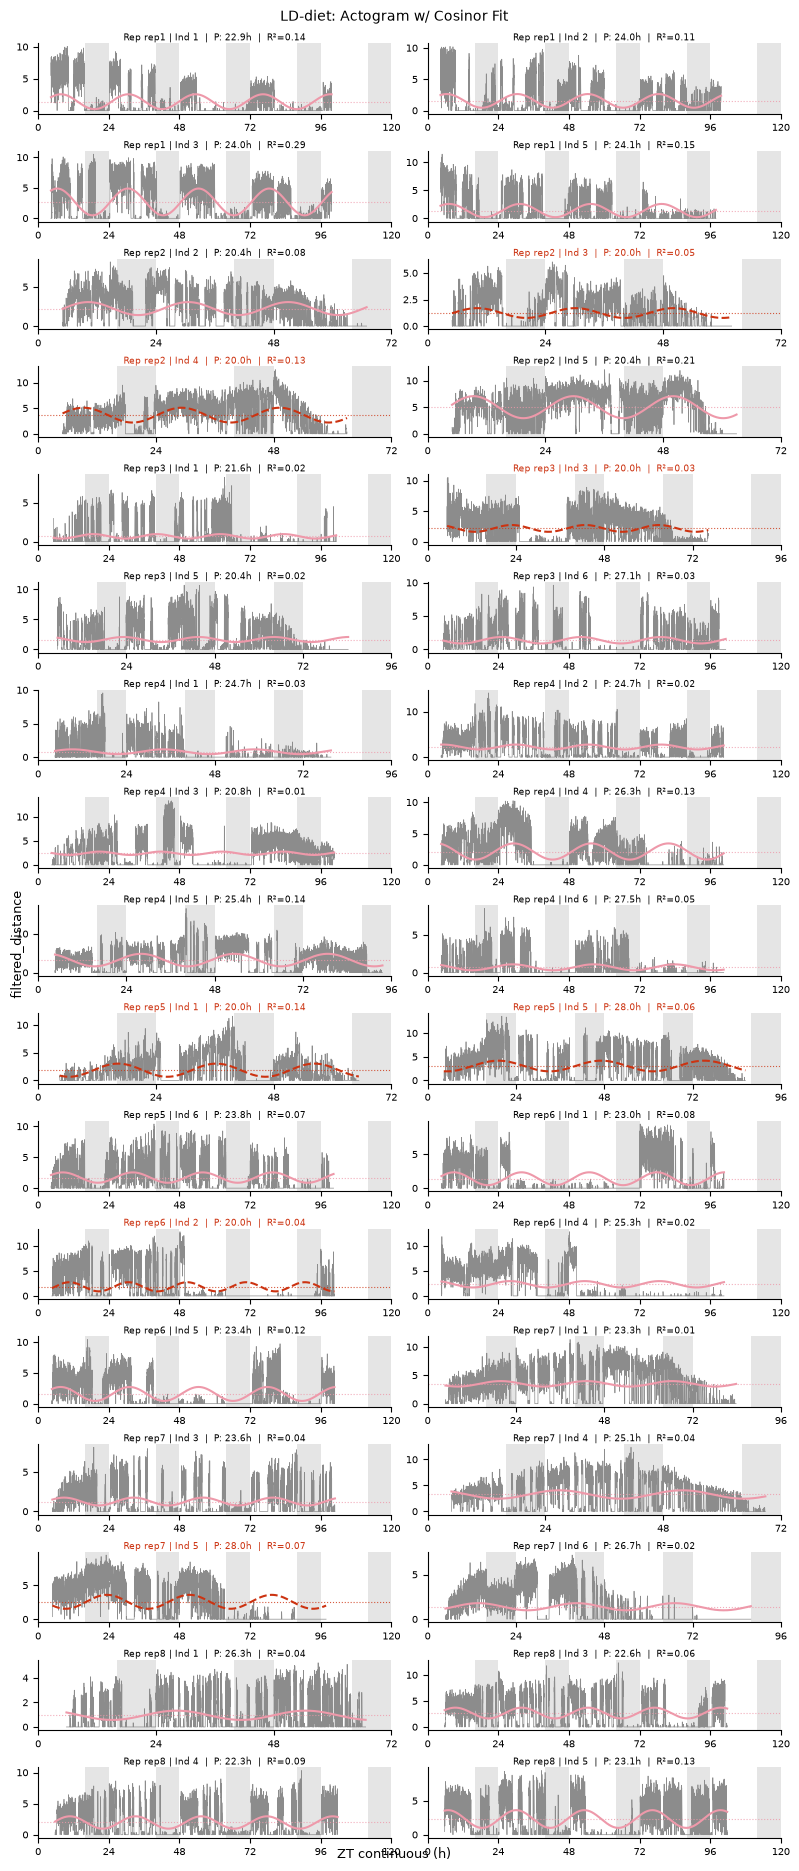

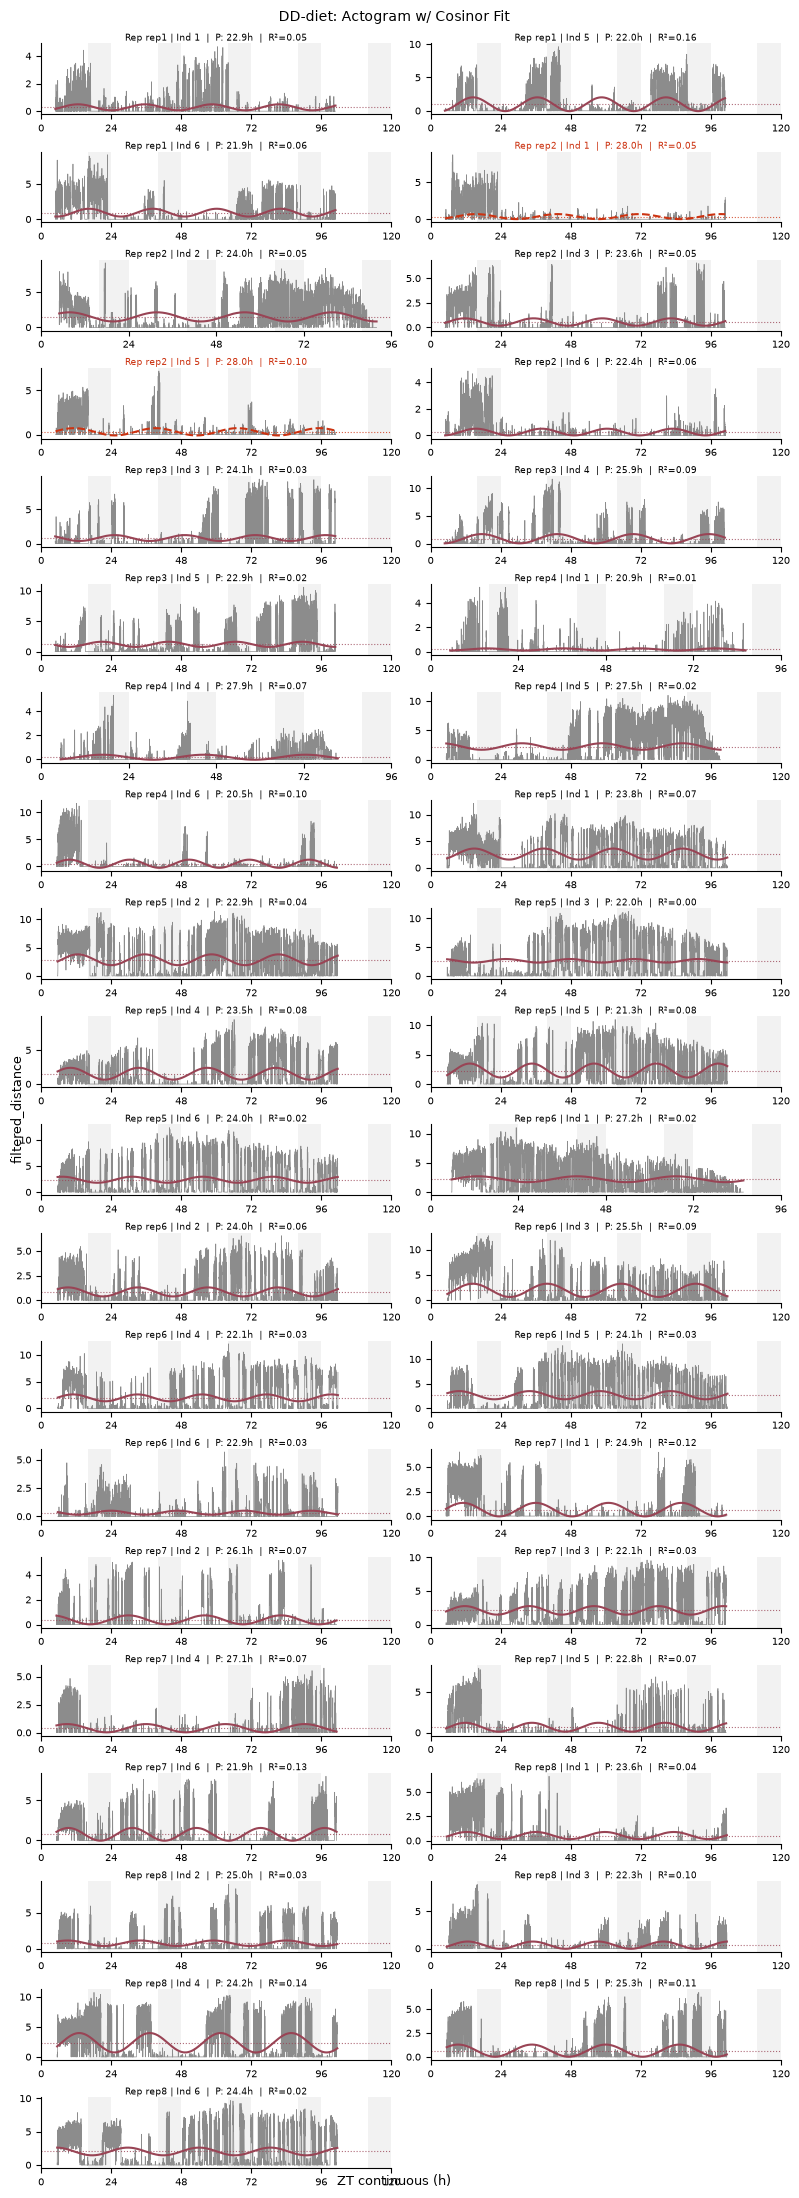

In [ ]:
# easier layout to see overtime...

SHOW_DARK_SHADING = True  
OVERLAY_NCOL      = 2  # 2 columns layout
TOTAL_WIDTH       = 8.0  # inches wide

TITLE_COLORS = {"": "black", "boundary": BOUNDARY_COLOR, "below_threshold": "0.45"}


def cosinor_curve(t, row):
    P = float(row["peak_period"])
    t_peak = float(row["phase_fraction"]) * P
    return float(row["mesor"]) + float(row["amplitude"]) * np.cos(2 * np.pi * (t - t_peak) / P)


def plot_cosinor_overlay(treatment, ncol=OVERLAY_NCOL, panel_size=(TOTAL_WIDTH / OVERLAY_NCOL, 1.1), save=False):
    sub = (stats_df[stats_df["treatment"] == treatment]
           .sort_values(["replicate", "individual"]))
    if sub.empty:
        print(f"No individuals for {treatment}")
        return

    n = len(sub)
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, squeeze=False,
                             figsize=(panel_size[0] * ncol, panel_size[1] * nrow))
    flat = axes.ravel()
    color = TREATMENT_COLORS.get(treatment, "black")
    is_dd = "DD" in treatment

    for ax, (_, row) in zip(flat, sub.iterrows()):
        d = (df[(df["treatment"] == row["treatment"]) &
                (df["replicate"] == row["replicate"]) &
                (df["individual"] == row["individual"])]
             .dropna(subset=[TIME_COL, VALUE_COL])
             .sort_values(TIME_COL))
        t = d[TIME_COL].to_numpy(dtype=float)
        y = d[VALUE_COL].to_numpy(dtype=float)
        if len(t) == 0:
            ax.axis("off")
            continue

        # dark / subjective-dark shading
        if SHOW_DARK_SHADING:
            for k in range(int(np.floor(t.min() / 24)), int(np.ceil(t.max() / 24)) + 1):
                ax.axvspan(DARK_START + 24 * k, DARK_END + 24 * k,
                           facecolor="grey", alpha=0.10 if is_dd else 0.20,
                           lw=0, zorder=0)

        ax.plot(t, y, color="0.55", lw=0.5, zorder=1)

        reason = row.get("arrhythmic_reason", "")
        fit_color = BOUNDARY_COLOR if reason == "boundary" else color
        fit_style = "--" if not row["is_rhythmic"] else "-"

        t_fine = np.linspace(t.min(), t.max(), 2000)
        ax.plot(t_fine, cosinor_curve(t_fine, row), color=fit_color, lw=1.5,
                ls=fit_style, zorder=3)
        ax.axhline(row["mesor"], color=fit_color, ls=":", lw=0.8, alpha=0.8, zorder=2)

        rel_amp = row["amplitude"] / row["mesor"] if row["mesor"] else np.nan
        title = (f"Rep {row['replicate']} | Ind {row['individual']}  |  "
                 f"P: {row['peak_period']:.1f}h  |  R\u00b2={row['cosinor_r2']:.2f}")
        ax.set_title(title, fontsize=6.5, pad=2, color=TITLE_COLORS.get(reason, "black"))

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(labelsize=7)
        ax.set_xlim(t.min(), t.max())
        ax.set_xticks(np.arange(0, t.max() + 24, 24))

    for ax in flat[n:]:
        ax.axis("off")

    fig.supxlabel("ZT continuous (h)", fontsize=9)
    fig.supylabel(VALUE_COL, fontsize=9)
    fig.suptitle(f"{treatment}: Actogram w/ Cosinor Fit", fontsize=10, y=1.0)
    plt.tight_layout(pad=0.3, w_pad=0.4, h_pad=0.5)

    if save:
        out = os.path.join(PLOT_DIR, f"Cosinor_Overlay_{treatment.replace('-', '_')}.svg")
        plt.savefig(out, format="svg", bbox_inches="tight")
        print(f"saved -> {out}")
    plt.show()


for _t in TREATMENTS:
    plot_cosinor_overlay(_t)

## 10. JTK_CYCLE

In [19]:
# cross checking results with JTK cycle.

from scipy.stats import kendalltau
from scipy.signal import lfilter
from scipy.linalg import toeplitz

JTK_BIN_HOURS = 0.5                              # even grid JTK requires
JTK_PERIODS   = np.arange(MIN_PERIOD, MAX_PERIOD + 1e-9, 0.5)


def bin_even(t, y, bin_h):
    """Average onto an evenly spaced grid; returns (t_centres, y_means) with gaps dropped."""
    edges = np.arange(t.min(), t.max() + bin_h, bin_h)
    idx = np.clip(np.digitize(t, edges) - 1, 0, len(edges) - 2)
    s = pd.Series(y).groupby(idx).mean()
    centres = edges[s.index.to_numpy()] + bin_h / 2
    return centres, s.to_numpy()


def jtk_cycle(t, y, periods=JTK_PERIODS, bin_h=JTK_BIN_HOURS):
    """JTK-style test: best Kendall tau against cosine reference waveforms.

    Returns best period, best phase, tau, and a Bonferroni-corrected p across templates.
    """
    best_p, best = 1.0, dict(period=np.nan, phase=np.nan, tau=np.nan)
    n_templates = 0
    for P in periods:
        n_phase = max(1, int(round(P / bin_h)))
        for k in range(n_phase):
            phase = k * bin_h
            ref = np.cos(2 * np.pi * (t - phase) / P)
            tau, p = kendalltau(y, ref)
            n_templates += 1
            if np.isfinite(p) and p < best_p:
                best_p = float(p)
                best = dict(period=float(P), phase=float(phase), tau=float(tau))
    return {**best, "p_raw": best_p, "n_templates": n_templates,
            "p_jtk": float(min(1.0, best_p * n_templates))}


def benjamini_hochberg(pvals):
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    adj = np.empty(n)
    running = 1.0
    for rank, i in enumerate(order[::-1]):
        running = min(running, p[i] * n / (n - rank))
        adj[i] = running
    return adj


jtk_rows = []
print(f"Running JTK on {JTK_BIN_HOURS:g} h bins, "
      f"periods {JTK_PERIODS.min():g}-{JTK_PERIODS.max():g} h ...")

for _, row in stats_df.iterrows():
    d = (df[(df["treatment"] == row["treatment"]) &
            (df["replicate"] == row["replicate"]) &
            (df["individual"] == row["individual"])]
         .dropna(subset=[TIME_COL, VALUE_COL]).sort_values(TIME_COL))
    tb, yb = bin_even(d[TIME_COL].to_numpy(float), d[VALUE_COL].to_numpy(float),
                      JTK_BIN_HOURS)
    res = jtk_cycle(tb, yb)
    jtk_rows.append({**{c: row[c] for c in GROUP_COLS},
                     "jtk_period": res["period"], "jtk_phase": res["phase"],
                     "jtk_tau": res["tau"], "jtk_p": res["p_jtk"],
                     "n_bins": len(tb)})

jtk_df = pd.DataFrame(jtk_rows)
jtk_df["jtk_q"] = benjamini_hochberg(jtk_df["jtk_p"])
jtk_df["jtk_sig"] = jtk_df["jtk_q"] < 0.05

stats_df = stats_df.merge(jtk_df, on=GROUP_COLS, how="left")

print("\nJTK significant (BH q < 0.05), by treatment:")
print(jtk_df.groupby("treatment")["jtk_sig"]
      .agg(n="size", n_sig="sum", pct=lambda s: 100 * s.mean()).round(1).to_string())

agree = (stats_df["is_rhythmic"] == stats_df["jtk_sig"]).mean()
print(f"\nAgreement with the Lomb-Scargle call: {100 * agree:.1f}% of individuals")
print(pd.crosstab(stats_df["is_rhythmic"], stats_df["jtk_sig"],
                  rownames=["LS rhythmic"], colnames=["JTK sig"]).to_string())
print("\nHigh agreement here is somewhat expected as both assume white noise...",
      "\n but It's always a good idea to run a few different tests.")

Running JTK on 0.5 h bins, periods 20-28 h ...

JTK significant (BH q < 0.05), by treatment:
            n  n_sig   pct
treatment                 
DD-diet    39     20  51.3
LD-diet    34     20  58.8

Agreement with the Lomb-Scargle call: 56.2% of individuals
JTK sig      False  True 
LS rhythmic              
False            5      4
True            28     36

High agreement here is somewhat expected as both assume white noise... 
 but It's always a good idea to run a few different tests.
